# Practice 3: Customer Clustering - Bước 7.2: Phân tích chân dung khách hàng từ cụm Hierarchical

---

## 1. Import các thư viện và tải dữ liệu

Chúng ta tải dữ liệu gốc đã làm sạch `Train_cleaned.csv` và nhãn phân cụm đại diện Hierarchical (huấn luyện trên 2000 mẫu con).

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')

# 1. Tải dữ liệu gốc sạch
df_raw = pd.read_csv('../data/processed/Train_cleaned.csv')

# 2. Tái tạo bộ chỉ số phân tách tập Train deterministically để phục vụ double-mapping
np.random.seed(42)
n_samples = len(df_raw)
n_val = int(n_samples * 0.2)
shuffled_indices = np.random.permutation(n_samples)
train_indices = shuffled_indices[n_val:]

# 3. Tải nhãn Hierarchical
labels_hier = pd.read_csv('../data/processed_features/hierarchical_labels_sklearn.csv')
sub_indices = labels_hier['Train_Sub_Index'].values

# 4. Double-mapping: Ánh xạ chỉ số mẫu con của X_train quay ngược lại dòng của df_raw
original_indices = train_indices[sub_indices]

# Trích xuất tập dữ liệu con gốc được gán nhãn
df_hier = df_raw.iloc[original_indices].copy()
df_hier['Cluster'] = labels_hier['Hierarchical_Label'].values

print(f'Kích thước dữ liệu mẫu con phân cụm Hierarchical: {df_hier.shape}')
print('Số lượng mẫu trong từng cụm Hierarchical:')
print(df_hier['Cluster'].value_counts())

Kích thước dữ liệu mẫu con phân cụm Hierarchical: (2000, 12)
Số lượng mẫu trong từng cụm Hierarchical:
Cluster
0    849
1    420
3    391
2    340
Name: count, dtype: int64


## 2. Thống kê đặc trưng số học theo cụm

Khảo sát các biến `Age`, `Work_Experience`, và `Family_Size`.

Age        Work_Experience        Family_Size       
              mean median            mean median        mean median
Cluster                                                            
0        53.293286   51.0        2.177856    1.0    2.583039    2.0
1        37.154762   36.0        3.047619    1.0    2.380952    2.0
2        45.511765   42.5        2.523529    1.0    3.191176    3.0
3        27.416880   25.0        2.670077    1.0    3.457801    4.0

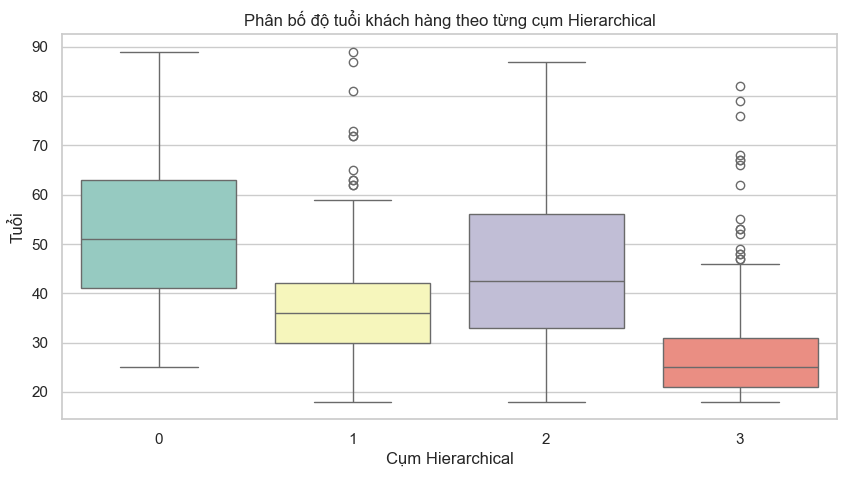

In [6]:
numerical_stats = df_hier.groupby('Cluster')[['Age', 'Work_Experience', 'Family_Size']].agg(['mean', 'median'])
display(numerical_stats)

# Vẽ phân bố độ tuổi của 4 cụm
plt.figure(figsize=(10, 5))
sns.boxplot(x='Cluster', y='Age', data=df_hier, hue='Cluster', palette='Set3', legend=False)
plt.title('Phân bố độ tuổi khách hàng theo từng cụm Hierarchical')
plt.xlabel('Cụm Hierarchical')
plt.ylabel('Tuổi')
plt.show()

## 3. Trực quan hóa tỷ lệ các đặc trưng nhân khẩu học theo cụm (Có gắn số liệu % cụ thể)

Chúng ta vẽ biểu đồ so sánh phân bố tỷ lệ phần trăm các đặc trưng phân loại quan trọng chéo theo cụm, hiển thị rõ số liệu tỷ lệ % trực tiếp trên cột.

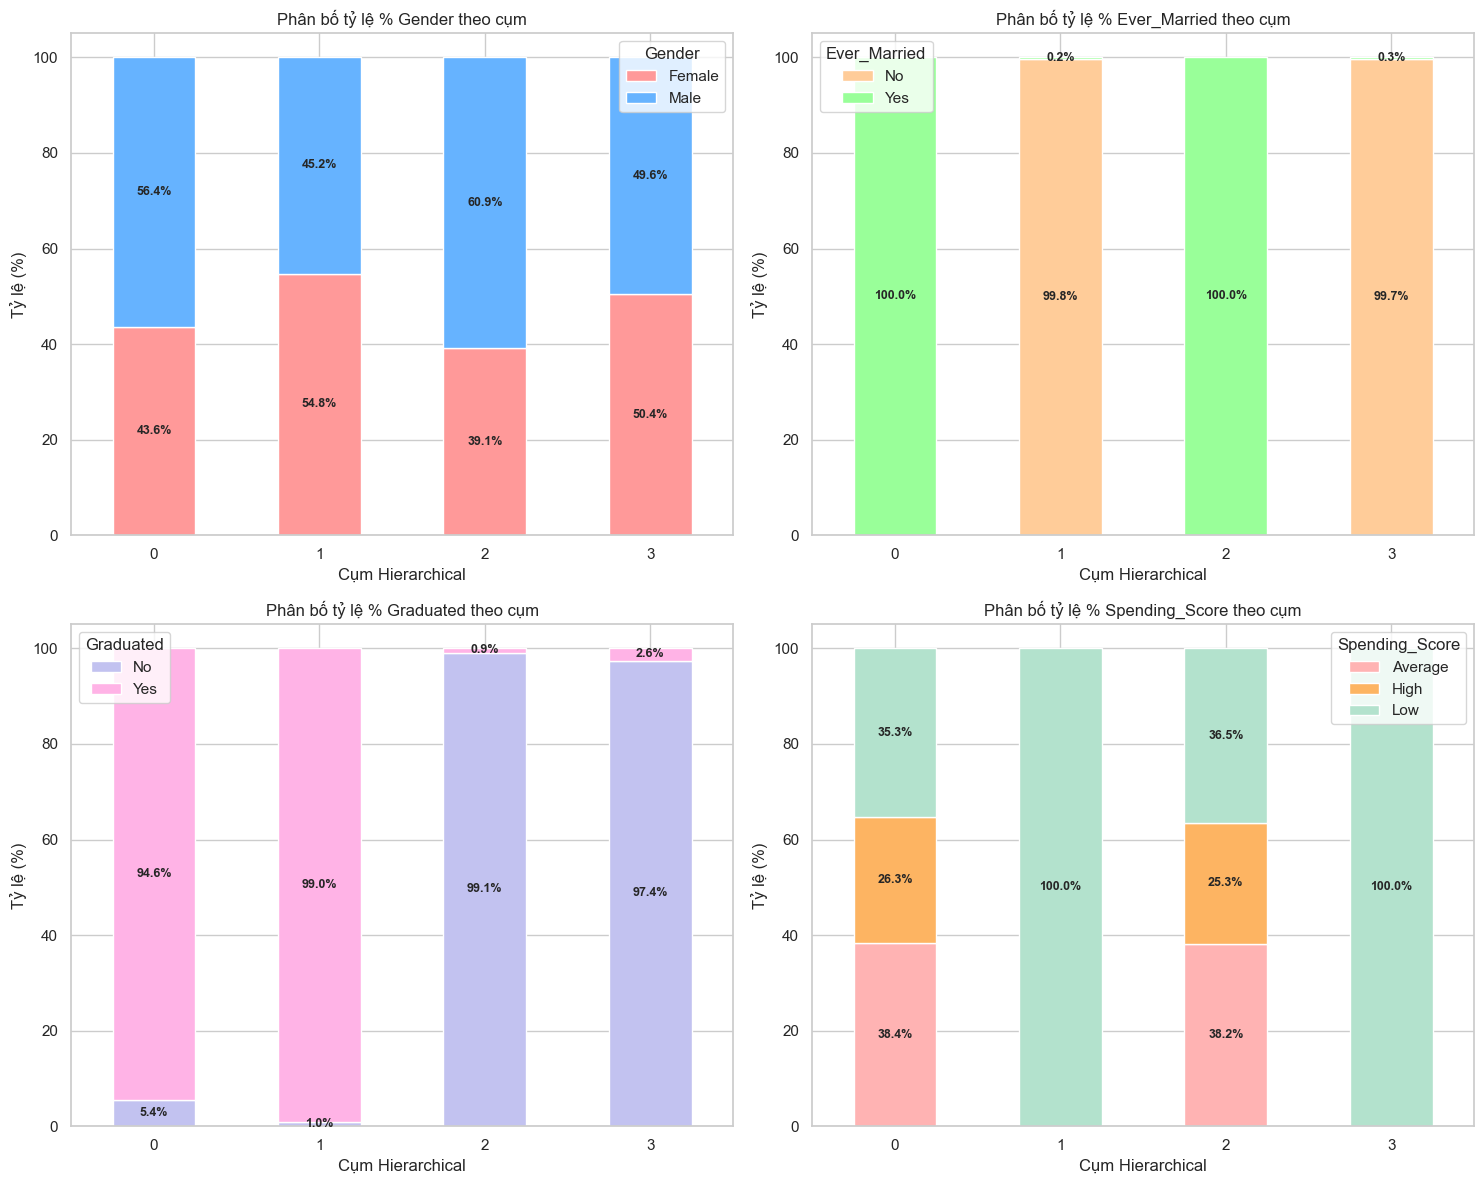

In [7]:
features = ['Gender', 'Ever_Married', 'Graduated', 'Spending_Score']
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

# Bảng màu tùy chỉnh hài hòa
colors_dict = {
    'Gender': ['#ff9999', '#66b3ff'],
    'Ever_Married': ['#ffcc99', '#99ff99'],
    'Graduated': ['#c2c2f0', '#ffb3e6'],
    'Spending_Score': ['#ffb3b3', '#fdb462', '#b3e2cd']
}

for idx, col in enumerate(features):
    cross_dist = pd.crosstab(df_hier['Cluster'], df_hier[col], normalize='index') * 100
    ax = axes[idx]
    cross_dist.plot(kind='bar', stacked=True, ax=ax, color=colors_dict[col])
    ax.set_title(f'Phân bố tỷ lệ % {col} theo cụm')
    ax.set_xlabel('Cụm Hierarchical')
    ax.set_ylabel('Tỷ lệ (%)')
    ax.legend(title=col)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    
    # Thêm nhãn số liệu phần trăm trực tiếp trên cột
    for container in ax.containers:
        labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in container]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

## 4. Trực quan hóa đặc trưng nổi trội của các cụm (Có hiển thị nhãn giá trị)

Chúng ta vẽ biểu đồ so sánh sự khác biệt lớn về Nghề nghiệp (`Profession`) và Mức độ chi tiêu (`Spending_Score`) giữa 4 cụm khách hàng.

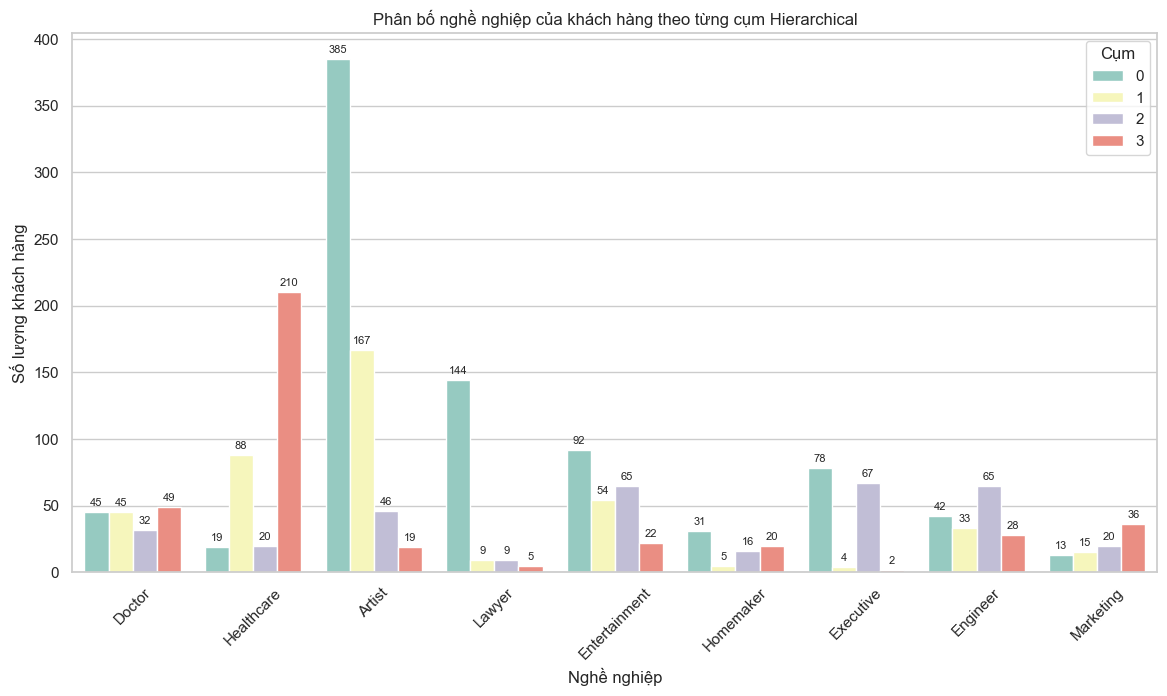

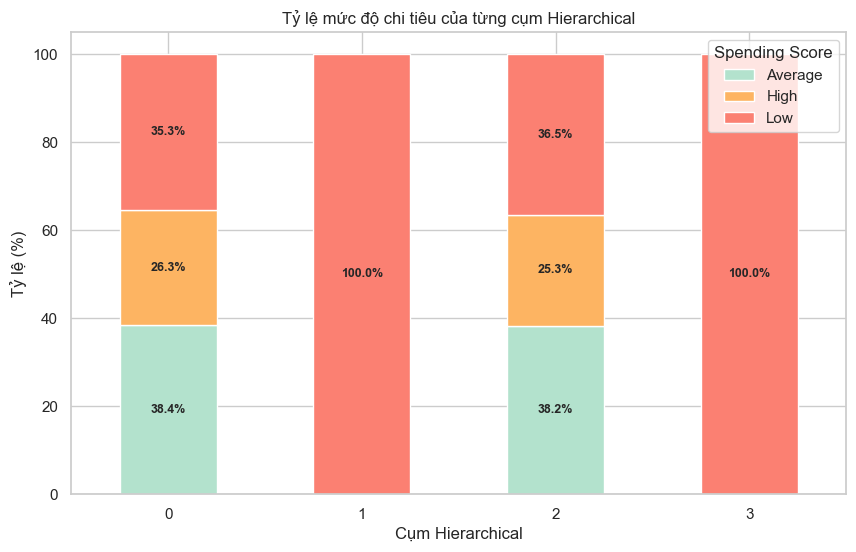

In [8]:
# 4.1. Phân bố Nghề nghiệp theo cụm
plt.figure(figsize=(14, 7))
ax1 = sns.countplot(x='Profession', hue='Cluster', data=df_hier, palette='Set3')
plt.title('Phân bố nghề nghiệp của khách hàng theo từng cụm Hierarchical')
plt.xlabel('Nghề nghiệp')
plt.ylabel('Số lượng khách hàng')
plt.xticks(rotation=45)
plt.legend(title='Cụm')

# Thêm nhãn số lượng mẫu trên cột
for container in ax1.containers:
    ax1.bar_label(container, fontsize=8, padding=3)
plt.show()

# 4.2. Phân bố Mức chi tiêu theo cụm
spending_dist = pd.crosstab(df_hier['Cluster'], df_hier['Spending_Score'], normalize='index') * 100
plt.figure(figsize=(10, 6))
ax2 = plt.gca()
spending_dist.plot(kind='bar', stacked=True, ax=ax2, color=['#b3e2cd', '#fdb462', '#fb8072'])
plt.title('Tỷ lệ mức độ chi tiêu của từng cụm Hierarchical')
plt.xlabel('Cụm Hierarchical')
plt.ylabel('Tỷ lệ (%)')
plt.xticks(rotation=0)
plt.legend(title='Spending Score')

# Thêm nhãn số liệu % trên cột chi tiêu
for container in ax2.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in container]
    ax2.bar_label(container, labels=labels, label_type='center', fontsize=9, weight='bold')

plt.show()

## 5. Định hình chân dung khách hàng mua ô tô (Concise Automobile Customer Personas)

* **Cụm 0: Khách hàng lớn tuổi thành đạt (Đã kết hôn & Tốt nghiệp)**
  * **Đặc trưng**: Tuổi ~53.3 | 100% Đã kết hôn | 94.6% Tốt nghiệp | Chi tiêu Trung bình/Cao | Artist (45.3%), Lawyer (17.0%).
  * **Dòng xe mục tiêu**: Xe sang cao cấp cỡ lớn (Executive Sedan/Premium SUV, Luxury EV).
   * **Chiến lược**: Tổ chức trải nghiệm lái thử VIP cá nhân hóa và cung cấp đặc quyền dịch vụ hậu mãi cao cấp.
   
* **Cụm 1: Khách hàng trẻ trí thức độc thân (Chưa kết hôn & Tốt nghiệp)**
  * **Đặc trưng**: Tuổi ~37.2 | 100% Độc thân | 99.0% Tốt nghiệp | 100% Chi tiêu Thấp | Artist (39.8%), Healthcare (21.0%).
  * **Dòng xe mục tiêu**: Crossover gầm cao năng động (C-SUV), xe điện thông minh kết nối hiện đại.
   * **Chiến lược**: Tiếp thị kỹ thuật số cá nhân hóa và các gói vay tài chính linh hoạt dài hạn.
   
* **Cụm 2: Khách hàng trung niên đã kết hôn chưa tốt nghiệp**
  * **Đặc trưng**: Tuổi ~45.5 | 100% Đã kết hôn | 99.1% Chưa tốt nghiệp | Chi tiêu Trung bình/Cao | Executive (19.7%), Entertainment (19.1%), Engineer (19.1%).
  * **Dòng xe mục tiêu**: MPV gia đình đa dụng rộng rãi, SUV 7 chỗ đa năng có độ bền bỉ cao.
   * **Chiến lược**: Nhấn mạnh các giá trị thực dụng (không gian gập ghế linh hoạt, chi phí bảo dưỡng tối ưu).
   
* **Cụm 3: Khách hàng trẻ tuổi tối giản (Chưa kết hôn & Chưa tốt nghiệp)**
  * **Đặc trưng**: Tuổi ~27.4 | 100% Độc thân | 97.4% Chưa tốt nghiệp | Gia đình lớn (~3.5 người) | 100% Chi tiêu Thấp | Healthcare (53.7%).
  * **Dòng xe mục tiêu**: Xe cỡ nhỏ hatchback hạng A giá rẻ, xe đã qua sử dụng chính hãng (Certified Pre-Owned - CPO).
   * **Chiến lược**: Đẩy mạnh các dòng xe CPO chất lượng cao có bảo hành dài hạn và gói tài chính tối giản cho người mua lần đầu.